<a href="https://colab.research.google.com/github/NEYEN111/incident-commander/blob/feature%2Fml-stats19/notebooks/ML_STATS19_Accidentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-2025.csv"

df = pd.read_csv(url)

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (101525, 44)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M101925,2025,17M101925,447673.0,519279.0,-1.26420,54.56650,17,3,1,...,-1,0,1,1,2,E01012014,3,1,0.0,1.0
1,202517L205225,2025,17L205225,454611.0,518597.0,-1.15704,54.55967,17,3,2,...,-1,0,1,1,2,E01012173,3,1,0.0,1.0
2,2025070971700,2025,070971700,354476.0,382656.0,-2.68516,53.33884,7,3,2,...,-1,0,2,1,2,E01012444,3,1,0.0,1.0
3,2025070403274,2025,070403274,361793.0,393163.0,-2.57655,53.43386,7,3,2,...,-1,0,2,3,2,E01012468,3,1,0.0,1.0
4,2025071000604,2025,071000604,366083.0,389327.0,-2.51157,53.39967,7,3,7,...,-1,0,2,1,1,E01012551,3,1,0.0,1.0


In [2]:
print(df["collision_severity"].value_counts().sort_index())

collision_severity
1     1453
2    25191
3    74881
Name: count, dtype: int64


In [3]:
df.columns.tolist()

['collision_index',
 'collision_year',
 'collision_ref_no',
 'location_easting_osgr',
 'location_northing_osgr',
 'longitude',
 'latitude',
 'police_force',
 'collision_severity',
 'number_of_vehicles',
 'number_of_casualties',
 'date',
 'day_of_week',
 'time',
 'local_authority_district',
 'local_authority_ons_district',
 'local_authority_highway',
 'local_authority_highway_current',
 'first_road_class',
 'first_road_number',
 'road_type',
 'speed_limit',
 'junction_detail_historic',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control_historic',
 'pedestrian_crossing_physical_facilities_historic',
 'pedestrian_crossing',
 'light_conditions',
 'weather_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards_historic',
 'carriageway_hazards',
 'urban_or_rural_area',
 'did_police_officer_attend_scene_of_accident',
 'trunk_road_flag',
 'lsoa_of_accident_location',
 'enhanced_severit

In [4]:
features = [
    "day_of_week",
    "time",
    "road_type",
    "speed_limit",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

for columna in features:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False).sort_index())


--- day_of_week ---
day_of_week
1    11197
2    14309
3    14880
4    15369
5    15304
6    16811
7    13655
Name: count, dtype: int64

--- time ---
time
00:00     18
00:01    103
00:02     28
00:03     23
00:04     15
        ... 
23:55     49
23:56     18
23:57     18
23:58     18
23:59     24
Name: count, Length: 1440, dtype: int64

--- road_type ---
road_type
1     6795
2     2398
3    14610
6    74150
7     1619
9     1953
Name: count, dtype: int64

--- speed_limit ---
speed_limit
20    20045
30    49673
40     8886
50     4612
60    12709
70     5600
Name: count, dtype: int64

--- urban_or_rural_area ---
urban_or_rural_area
1    67148
2    34373
3        4
Name: count, dtype: int64

--- light_conditions ---
light_conditions
-1       16
 1    72814
 4    20705
 5      720
 6     5682
 7     1588
Name: count, dtype: int64

--- weather_conditions ---
weather_conditions
1    83405
2    10230
3      235
4      715
5      880
6       19
7      342
8     3314
9     2385
Name: count, dt

In [5]:
df[features].info()

print("\nValores nulos:")
print(df[features].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101525 entries, 0 to 101524
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   day_of_week              101525 non-null  int64 
 1   time                     101525 non-null  object
 2   road_type                101525 non-null  int64 
 3   speed_limit              101525 non-null  int64 
 4   urban_or_rural_area      101525 non-null  int64 
 5   light_conditions         101525 non-null  int64 
 6   weather_conditions       101525 non-null  int64 
 7   road_surface_conditions  101525 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 6.2+ MB

Valores nulos:
day_of_week                0
time                       0
road_type                  0
speed_limit                0
urban_or_rural_area        0
light_conditions           0
weather_conditions         0
road_surface_conditions    0
dtype: int64


In [6]:
datos = df[
    [
        "collision_severity",
        "day_of_week",
        "time",
        "road_type",
        "speed_limit",
        "urban_or_rural_area",
        "light_conditions",
        "weather_conditions",
        "road_surface_conditions"
    ]
].copy()

datos["hour"] = pd.to_datetime(
    datos["time"],
    format="%H:%M",
    errors="coerce"
).dt.hour

datos[["time", "hour"]].head(10)

,time,hour
0,15:00,15
1,09:35,9
2,18:18,18
3,16:30,16
4,07:45,7
5,12:11,12
6,11:45,11
7,17:31,17
8,16:00,16
9,16:40,16


In [7]:
print("Horas inválidas:", datos["hour"].isna().sum())
print("Hora mínima:", datos["hour"].min())
print("Hora máxima:", datos["hour"].max())

Horas inválidas: 0
Hora mínima: 0
Hora máxima: 23


In [8]:
# Traducimos el target para que los resultados sean más fáciles de interpretar
mapa_gravedad = {
    1: "Fatal",
    2: "Grave",
    3: "Leve"
}

datos["gravedad"] = datos["collision_severity"].map(mapa_gravedad)

# Variables que utilizará el modelo
columnas_modelo = [
    "day_of_week",
    "hour",
    "road_type",
    "speed_limit",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

X = datos[columnas_modelo].copy()
y = datos["gravedad"].copy()

print("X:", X.shape)
print("y:", y.shape)

print("\nPrimeras variables:")
display(X.head())

print("\nClases del target:")
print(y.value_counts())

X: (101525, 8)
y: (101525,)

Primeras variables:


,day_of_week,hour,road_type,speed_limit,urban_or_rural_area,light_conditions,weather_conditions,road_surface_conditions
0,3,15,6,30,1,1,1,1
1,4,9,6,30,1,1,1,1
2,5,18,6,30,2,4,1,2
3,5,16,6,40,2,1,1,1
4,2,7,3,70,2,4,1,2



Clases del target:
gravedad
Leve     74881
Grave    25191
Fatal     1453
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución prueba:")
print(y_test.value_counts(normalize=True))

Entrenamiento: (81220, 8)
Prueba: (20305, 8)

Distribución entrenamiento:
gravedad
Leve     0.737565
Grave    0.248129
Fatal    0.014307
Name: proportion, dtype: float64

Distribución prueba:
gravedad
Leve     0.737552
Grave    0.248116
Fatal    0.014331
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

columnas_numericas = [
    "hour",
    "speed_limit"
]

columnas_categoricas = [
    "day_of_week",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

print("Preprocesador preparado correctamente.")

Preprocesador preparado correctamente.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

baseline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_baseline = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro"
    },
    n_jobs=-1
)

print("Baseline")
print("Accuracy:",
      resultados_baseline["test_accuracy"].mean())

print("Balanced Accuracy:",
      resultados_baseline["test_balanced_accuracy"].mean())

print("F1 Macro:",
      resultados_baseline["test_f1_macro"].mean())

Baseline
Accuracy: 0.7375646392514159
Balanced Accuracy: 0.3333333333333333
F1 Macro: 0.282987894892235


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)

modelo_logistico = Pipeline([
    ("preprocesamiento", preprocessor),
    ("modelo", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

metricas = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),
    "recall_macro": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),
    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    )
}

resultados_logistico = cross_validate(
    modelo_logistico,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

print("Logistic Regression")
print("Accuracy:",
      resultados_logistico["test_accuracy"].mean())

print("Balanced Accuracy:",
      resultados_logistico["test_balanced_accuracy"].mean())

print("Precision Macro:",
      resultados_logistico["test_precision_macro"].mean())

print("Recall Macro:",
      resultados_logistico["test_recall_macro"].mean())

print("F1 Macro:",
      resultados_logistico["test_f1_macro"].mean())

Logistic Regression
Accuracy: 0.4529303127308545
Balanced Accuracy: 0.4577511911140606
Precision Macro: 0.3571178112964522
Recall Macro: 0.4577511911140606
F1 Macro: 0.315009639200017


In [13]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = Pipeline([
    ("preprocesamiento", preprocessor),
    ("modelo", DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

resultados_arbol = cross_validate(
    modelo_arbol,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

print("Decision Tree")
print("Accuracy:",
      resultados_arbol["test_accuracy"].mean())

print("Balanced Accuracy:",
      resultados_arbol["test_balanced_accuracy"].mean())

print("Precision Macro:",
      resultados_arbol["test_precision_macro"].mean())

print("Recall Macro:",
      resultados_arbol["test_recall_macro"].mean())

print("F1 Macro:",
      resultados_arbol["test_f1_macro"].mean())

Decision Tree
Accuracy: 0.4528564393006649
Balanced Accuracy: 0.4240239969274919
Precision Macro: 0.3537584513651396
Recall Macro: 0.4240239969274919
F1 Macro: 0.3099263842954308


In [14]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("preprocesamiento", preprocessor),
    ("modelo", RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

resultados_rf = cross_validate(
    modelo_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=1
)

print("Random Forest")
print("Accuracy:",
      resultados_rf["test_accuracy"].mean())

print("Balanced Accuracy:",
      resultados_rf["test_balanced_accuracy"].mean())

print("Precision Macro:",
      resultados_rf["test_precision_macro"].mean())

print("Recall Macro:",
      resultados_rf["test_recall_macro"].mean())

print("F1 Macro:",
      resultados_rf["test_f1_macro"].mean())

Random Forest
Accuracy: 0.5310145284412706
Balanced Accuracy: 0.450241409695319
Precision Macro: 0.36092528590298156
Recall Macro: 0.450241409695319
F1 Macro: 0.3363036665845983


In [15]:
import xgboost as xgb

print("Versión XGBoost:", xgb.__version__)

Versión XGBoost: 3.4.1


In [16]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

# XGBoost utilizará números para las clases
mapa_xgb = {
    "Leve": 0,
    "Grave": 1,
    "Fatal": 2
}

y_train_xgb = y_train.map(mapa_xgb)

resultados_xgb = []

for fold, (idx_train, idx_val) in enumerate(
    cv.split(X_train, y_train_xgb),
    start=1
):
    X_tr = X_train.iloc[idx_train]
    X_val = X_train.iloc[idx_val]

    y_tr = y_train_xgb.iloc[idx_train]
    y_val = y_train_xgb.iloc[idx_val]

    # Da más importancia a las clases minoritarias
    pesos = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    modelo_xgb = Pipeline([
        ("preprocesamiento", clone(preprocessor)),
        ("modelo", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=200,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss"
        ))
    ])

    modelo_xgb.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=pesos
    )

    pred = modelo_xgb.predict(X_val)

    resultados_xgb.append({
        "accuracy": accuracy_score(y_val, pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, pred),
        "precision_macro": precision_score(
            y_val, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_val, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_val, pred, average="macro", zero_division=0
        )
    })

resultados_xgb = pd.DataFrame(resultados_xgb)

print("XGBoost")
print(resultados_xgb.mean())

XGBoost
accuracy             0.478663
balanced_accuracy    0.448179
precision_macro      0.357060
recall_macro         0.448179
f1_macro             0.321304
dtype: float64


In [17]:
candidatas_nuevas = [
    "number_of_vehicles",
    "junction_detail",
    "junction_control",
    "first_road_class"
]

for columna in candidatas_nuevas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False).sort_index())


--- number_of_vehicles ---
number_of_vehicles
1     30841
2     61869
3      6876
4      1331
5       405
6       109
7        58
8        18
9         7
10        5
11        2
12        3
17        1
Name: count, dtype: int64

--- junction_detail ---
junction_detail
-1      6701
 0     45333
 13    28198
 16     9456
 17     1504
 18     2144
 19     6762
 99     1427
Name: count, dtype: int64

--- junction_control ---
junction_control
-1    44487
 1      381
 2    10580
 3      649
 4    41902
 9     3526
Name: count, dtype: int64

--- first_road_class ---
first_road_class
-1        6
 1     3054
 2      198
 3    43827
 4    12975
 5     4564
 6    36901
Name: count, dtype: int64


In [18]:
X_mejorado = df[
    [
        "day_of_week",
        "road_type",
        "speed_limit",
        "urban_or_rural_area",
        "light_conditions",
        "weather_conditions",
        "road_surface_conditions",
        "number_of_vehicles",
        "junction_detail",
        "first_road_class"
    ]
].copy()

# Crear nuevamente la hora
X_mejorado["hour"] = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
).dt.hour

# Reutilizamos EXACTAMENTE los mismos registros
# de entrenamiento y prueba que antes
X_train2 = X_mejorado.loc[X_train.index]
X_test2 = X_mejorado.loc[X_test.index]

print("Entrenamiento:", X_train2.shape)
print("Prueba:", X_test2.shape)

X_train2.head()

Entrenamiento: (81220, 11)
Prueba: (20305, 11)


,day_of_week,road_type,speed_limit,urban_or_rural_area,light_conditions,weather_conditions,road_surface_conditions,number_of_vehicles,junction_detail,first_road_class,hour
67014,7,6,30,1,1,1,1,3,0,6,20
29253,1,6,60,2,1,1,1,1,0,5,11
33443,5,3,20,1,1,1,1,2,13,6,8
70108,2,1,20,1,1,1,1,2,-1,5,19
34735,2,6,40,2,1,2,2,2,0,3,13


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

columnas_numericas2 = [
    "hour",
    "speed_limit",
    "number_of_vehicles"
]

columnas_categoricas2 = [
    "day_of_week",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "junction_detail",
    "first_road_class"
]

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas2)
    ]
)

print("Nuevo preprocesador preparado.")

Nuevo preprocesador preparado.


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

modelo_logistico2 = Pipeline([
    ("preprocesamiento", preprocessor2),
    ("modelo", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

resultados_logistico2 = cross_validate(
    modelo_logistico2,
    X_train2,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=-1
)

print("Logistic Regression - 11 variables")
print("Accuracy:",
      resultados_logistico2["test_accuracy"].mean())
print("Balanced Accuracy:",
      resultados_logistico2["test_balanced_accuracy"].mean())
print("Precision Macro:",
      resultados_logistico2["test_precision_macro"].mean())
print("Recall Macro:",
      resultados_logistico2["test_recall_macro"].mean())
print("F1 Macro:",
      resultados_logistico2["test_f1_macro"].mean())

Logistic Regression - 11 variables
Accuracy: 0.4523516375277025
Balanced Accuracy: 0.4692704596050423
Precision Macro: 0.3676319776586835
Recall Macro: 0.4692704596050423
F1 Macro: 0.32147109685461195


In [21]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf2 = Pipeline([
    ("preprocesamiento", preprocessor2),
    ("modelo", RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

resultados_rf2 = cross_validate(
    modelo_rf2,
    X_train2,
    y_train,
    cv=cv,
    scoring=metricas,
    n_jobs=1
)

print("Random Forest - 11 variables")

print("Accuracy:",
      resultados_rf2["test_accuracy"].mean())

print("Balanced Accuracy:",
      resultados_rf2["test_balanced_accuracy"].mean())

print("Precision Macro:",
      resultados_rf2["test_precision_macro"].mean())

print("Recall Macro:",
      resultados_rf2["test_recall_macro"].mean())

print("F1 Macro:",
      resultados_rf2["test_f1_macro"].mean())

Random Forest - 11 variables
Accuracy: 0.5518837724698351
Balanced Accuracy: 0.4634255629121789
Precision Macro: 0.3798304059593217
Recall Macro: 0.4634255629121789
F1 Macro: 0.3663108270383573


In [22]:
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

resultados_xgb2 = []

for fold, (idx_train, idx_val) in enumerate(
    cv.split(X_train2, y_train),
    start=1
):
    X_tr = X_train2.iloc[idx_train]
    X_val = X_train2.iloc[idx_val]

    y_tr_texto = y_train.iloc[idx_train]
    y_val_texto = y_train.iloc[idx_val]

    y_tr = y_tr_texto.map(mapa_xgb)
    y_val = y_val_texto.map(mapa_xgb)

    pesos = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    modelo_xgb2 = Pipeline([
        ("preprocesamiento", clone(preprocessor2)),
        ("modelo", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            n_estimators=200,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss"
        ))
    ])

    modelo_xgb2.fit(
        X_tr,
        y_tr,
        modelo__sample_weight=pesos
    )

    pred = modelo_xgb2.predict(X_val)

    resultados_xgb2.append({
        "accuracy": accuracy_score(y_val, pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, pred),
        "precision_macro": precision_score(
            y_val, pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_val, pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_val, pred, average="macro", zero_division=0
        )
    })

resultados_xgb2 = pd.DataFrame(resultados_xgb2)

print("XGBoost - 11 variables")
print(resultados_xgb2.mean())

XGBoost - 11 variables
accuracy             0.514689
balanced_accuracy    0.469033
precision_macro      0.375581
recall_macro         0.469033
f1_macro             0.346157
dtype: float64


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline_rf = Pipeline([
    ("preprocesamiento", preprocessor2),
    ("modelo", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

parametros = {
    "modelo__n_estimators": [150, 250, 350],
    "modelo__max_depth": [12, 16, 20],
    "modelo__min_samples_leaf": [5, 10, 20]
}

busqueda_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=parametros,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busqueda_rf.fit(X_train2, y_train)

print("Mejores parámetros:")
print(busqueda_rf.best_params_)

print("\nMejor F1 Macro CV:")
print(busqueda_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros:
{'modelo__n_estimators': 150, 'modelo__min_samples_leaf': 5, 'modelo__max_depth': 16}

Mejor F1 Macro CV:
0.37363332510113906


RESULTADOS FINALES EN TEST
Accuracy: 0.557744397931544
Balanced Accuracy: 0.461836400323646
Precision Macro: 0.3759086167354386
Recall Macro: 0.461836400323646
F1 Macro: 0.3662578552185292

REPORTE POR CLASE
              precision    recall  f1-score   support

       Fatal       0.05      0.42      0.09       291
       Grave       0.29      0.32      0.31      5038
        Leve       0.79      0.64      0.71     14976

    accuracy                           0.56     20305
   macro avg       0.38      0.46      0.37     20305
weighted avg       0.65      0.56      0.60     20305



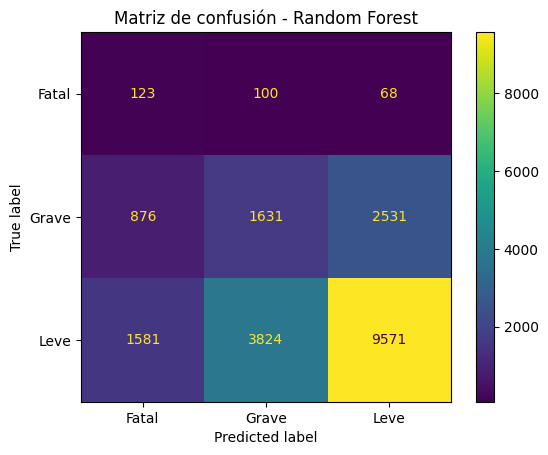

ROC-AUC Macro OVR: 0.6259265021023273


In [24]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt

# Mejor modelo encontrado
modelo_final = busqueda_rf.best_estimator_

# Predicción sobre el conjunto de prueba FINAL
y_pred = modelo_final.predict(X_test2)

# Métricas generales
print("RESULTADOS FINALES EN TEST")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Precision Macro:", precision_score(
    y_test, y_pred, average="macro", zero_division=0
))
print("Recall Macro:", recall_score(
    y_test, y_pred, average="macro", zero_division=0
))
print("F1 Macro:", f1_score(
    y_test, y_pred, average="macro", zero_division=0
))

print("\nREPORTE POR CLASE")
print(classification_report(
    y_test,
    y_pred,
    labels=["Fatal", "Grave", "Leve"],
    zero_division=0
))

# Matriz de confusión
matriz = confusion_matrix(
    y_test,
    y_pred,
    labels=["Fatal", "Grave", "Leve"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Fatal", "Grave", "Leve"]
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

# ROC-AUC multiclase
probabilidades = modelo_final.predict_proba(X_test2)
clases = modelo_final.named_steps["modelo"].classes_

auc_macro = roc_auc_score(
    y_test,
    probabilidades,
    multi_class="ovr",
    average="macro",
    labels=clases
)

print("ROC-AUC Macro OVR:", auc_macro)